In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tkinter as tk

from tkinter import messagebox, ttk

In [2]:
produk = pd.read_csv('product_category.csv')

In [3]:
X = produk.drop('Label', axis=1)
y = produk['Label']

In [4]:
X = (X - X.mean()) / X - X.std()

In [5]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    idx_0 = np.where(y == 0)[0]
    idx_1 = np.where(y == 1)[0]

    np.random.shuffle(idx_0)
    np.random.shuffle(idx_1)

    train_0 = int(len(idx_0) * size)
    train_1 = int(len(idx_1) * size)

    train_idx = np.concatenate([idx_0[:train_0], idx_1[:train_1]])
    test_idx = np.concatenate([idx_0[train_0:], idx_1[train_1:]])

    np.random.shuffle(train_idx)
    np.random.shuffle(test_idx)

    X_train = X.iloc[train_idx].values
    y_train = y.iloc[train_idx].values
    X_test = X.iloc[test_idx].values
    y_test = y.iloc[test_idx].values

    return X_train, y_train, X_test, y_test

In [6]:
X_train, y_train, X_test, y_test = split_data(X, y, size=0.8)

In [7]:
def scaling(X):
    n_features = len(X[0])
    mean = []
    std = []

    for j in range(n_features):
        column = [row[j] for row in X]
        m = sum(column) / len(column) # Menghitung mean
        s = (sum((x - m)**2 for x in column) / len(column))**0.5 #menghitung std
        mean.append(m)
        std.append(s)
    return mean, std

def apply(X, mean, std):
    X_scaled = []
    for row in X:
        new_row = []
        for j in range(len(row)):
            scaled = (row[j] - mean[j]) / (std[j] + 1e-9) #standar deviasi
            new_row.append(scaled)
        X_scaled.append(new_row)
    return X_scaled

mean, std = scaling(X_train)

X_train_scaled = apply(X_train, mean, std)
X_test_scaled = apply(X_test, mean, std)

In [8]:
def train_svm(X, y, learning_rate=0.000001, lambda_param=0.001, n_iters=20000):
    n_sampled, n_features = len(X), len(X[0])
    w = [0.0] * n_features
    b = 0.0
    y_svm = [1 if val == 1 else -1 for val in y] # menjadikan ke format svm

    for _ in range(n_iters):
        for idx, x_i in enumerate(X):
            y_i = y_svm[idx]
            approx = sum(x_i[j] * w[j] for j in range(n_features)) + b # hitung prediksi
            condition = y_i * approx >= 1

            if condition:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j])
            else:
                for j in range(n_features):
                    w[j] -= learning_rate * (2 * lambda_param * w[j] - x_i[j] * y_i)
                b -= learning_rate * y_i
    return w, b

weights, bias = train_svm(X_train, y_train)

In [9]:
def predict(X, w, b):
    predictions = []
    for x_i in X:
        approx = sum(x_i[j] * w[j] for j in range(len(w))) + b
        predictions.append(1 if approx >= 0 else -1)
    return predictions

y_pred_test = predict(X_test_scaled, weights, bias)
y_pred_train = predict(X_train_scaled, weights, bias)

In [10]:
def calculate_accuracy(y_true, y_pred):
    y_true_converted = [1 if x == 1 else -1 for x in y_true]

    correct_predictions = 0
    for i in range(len(y_true_converted)):
        if y_true_converted[i] == y_pred[i]:
            correct_predictions += 1

    return (correct_predictions / len(y_true_converted)) * 100

accuracy_test = calculate_accuracy(y_test, y_pred_test)
accuracy_train = calculate_accuracy(y_train, y_pred_train)

In [11]:
def calculate_metrics(y_true, y_pred):
    y_true_converted = [1 if x == 1 else -1 for x in y_true]
    tp, fp, fn, tn = 0, 0, 0, 0

    for i in range(len(y_true_converted)):
        if y_true_converted[i] == 1 and y_pred[i] == 1:
            tp += 1
        elif y_true_converted[i] == -1 and y_pred[i] == 1:
            fp += 1
        elif y_true_converted[i] == 1 and y_pred[i] == -1:
            fn += 1
        elif y_true_converted[i] == -1 and y_pred[i] == -1:
            tn += 1

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return precision, recall, f1_score

precision, recall, f1_score = calculate_metrics(y_test, y_pred_test)

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")
print(f"Accuracy Test: {accuracy_test:.2f}%")
print(f"Accuracy Train: {accuracy_train:.2f}%")

Precision: 1.0000
Recall: 0.9500
F1-Score: 0.9744
Accuracy Test: 97.50%
Accuracy Train: 98.75%


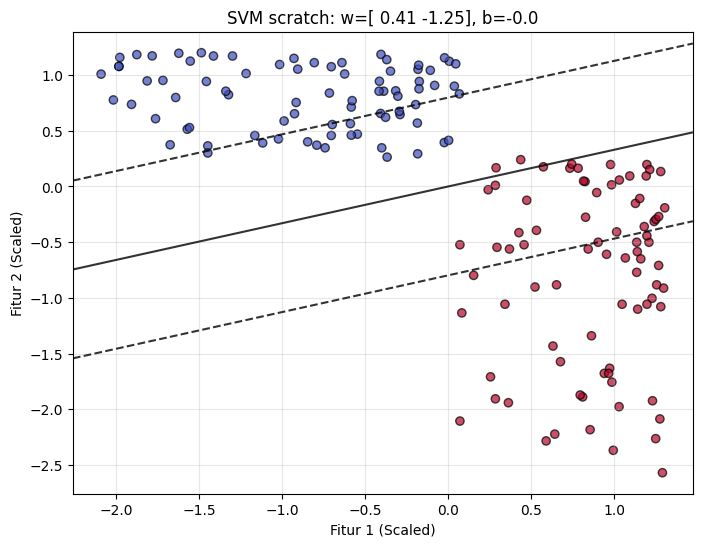

In [34]:


def visualize_svm_final(X, y, weights, bias):
    X = np.array(X)
    y = np.array(y)
    w = np.array(weights)

    plt.figure(figsize=(8, 6))

    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', alpha=0.7, edgecolors='k')

    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)

    Z = (w[0] * XX + w[1] * YY + bias)

    ax.contour(XX, YY, Z, colors='Black', levels=[-1, 0, 1], alpha=0.8,
               linestyles=['--', '-', '--'])

    plt.title(f"SVM scratch: w={w.round(2)}, b={round(bias, 2)}")
    plt.xlabel("Fitur 1 (Scaled)")
    plt.ylabel("Fitur 2 (Scaled)")
    plt.grid(True, alpha=0.3)
    plt.show()

visualize_svm_final(X_train_scaled, y_train, weights, bias)

In [38]:
def confusion_matrix(y_true, y_pred):
    labels = np.unique(np.concatenate(y_true, y_pred))
    label_idx = {label: i for i, label in enumerate(labels)}

    cm = np.zeros((len(labels), len(labels)), dtype=int)
    for yt, yp in zip(y_true, y_pred):
        i = label_idx[yt]
        j = label_idx[yp]
        cm[i, j] += 1
    return cm, labels

cm, labels =  confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm, annot=True, cmap='Blues')
plt.xlabel('Label')
plt.ylabel('Prediksi')
plt.title('Confusion Matrix')
plt.show()

TypeError: 'list' object cannot be interpreted as an integer

In [ ]:
root = tk.Tk()
root.configure(bg="#1E1D1F")

def button_prediksi():
    try:
        input_produk = float(entry1.get())
        input_weight = float(entry2.get())
        input_scaled = [(input_produk - mean[0]) / (std[0] + 1e-9),
                        (input_weight - mean[1]) / (std[1] + 1e-9)]
        prediction = predict([input_scaled], weights, bias)[0]
        kategori = "Kategori 1" if prediction == 1 else "Kategori 0"
        messagebox.showinfo("Hasil Prediksi", f"Produk termasuk dalam: {kategori}")
    except ValueError:
        messagebox.showerror("Input Error", "Masukkan nilai numerik yang valid.")
    return

# frame
frame = tk.Frame(root)
frame.configure(bg="#1E1D1F")
frame.place(relx=0.5, rely=0.30, anchor='center')

# label1
label1 = tk.Label(frame,
                  text="Klasifikasi Produk",
                  font=('Arial', 25, 'bold'),
                  bg="#1E1D1F",
                  fg="#FFFFFF")
label1.pack()

# label2
label2 = tk.Label(frame,
                  text="Weights",
                  font=("Arial", 15, "bold"),
                  bg=('#1E1D1F'),
                  fg=('#FFFFFF'))
label2.pack(pady=30)

# entry1
entry1 = tk.Entry(frame,
                  font=("Arial", 20),
                  bg="#4C4B4C",
                  fg='#FFFFFF')
entry1.pack()

# label3
label3 = tk.Label(frame,
                  text="Price",
                  font=("Arial", 15, "bold"),
                  bg=('#1E1D1F'),
                  fg=('#FFFFFF'))
label3.pack(pady=15)

# entry2
entry2 = tk.Entry(frame,
                  font=("Arial", 20),
                  bg="#4C4B4C",
                  fg='#FFFFFF')
entry2.pack(pady=15)

# button1
button1 = tk.Button(frame,
                    text="Press",
                    font=("Arial", 15),
                    bg="#4C4B4C",
                    fg="#FFFFFF",
                    command=button_prediksi)
button1.pack(pady=30)

root.mainloop()

In [30]:
produk.sample(10)

,Weight,Price,Label
138,2962,203,1
70,905,585,0
63,1005,528,0
134,2229,485,1
66,1187,659,0
132,2653,425,1
193,2315,250,1
115,1941,267,1
144,1793,419,1
175,2821,303,1
